# Convection speed analysis

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Callable
from globals import main_dir,data_dir
import pickle
import pandas as pd
from Rotor import Rotor

In [15]:
j = 1.2
R = 0.7
n_elem=40
Vinf = np.array([60,0,0])
n = Vinf[0]/(j*2*R)
Ome  = n*2*np.pi
Vinf = np.array([60,0,0])
Vinf_wing = np.array([1,0,0])
c_R_func:Callable = lambda r_R : 0.18-0.06*r_R
twst_func:Callable = lambda r_R : -50*r_R+35
wing_c_R_func:Callable = lambda r_R: np.ones(shape=r_R.shape)/10 #=1
wing_twst_func:Callable = lambda r_R : r_R*0

In [23]:
a_wake_lst = np.linspace(0,0.5,10)
perf_lst = []
for a_wake in a_wake_lst:
    rotor = Rotor(B=6,
                    R=R,
                    r_R_H=0.25,
                    c_R_func=c_R_func,
                    twst_func=twst_func,
                    pitch=45,
                    polar_path=data_dir.joinpath("ARAD8pct_polar.txt"),
                    Omega = Ome,
                    Vinf=Vinf,
                    a_wake=a_wake,
                    rho=1.067,
                    n_elem=n_elem,
                    dist_elem="uniform",
                    periods = 1,
                    n_elems_per_wake=10
                    )
    rotor.solve()
    perf_dict = rotor.calculate_spanwise_performance()
    perf_lst.append(perf_dict)

Converged in 61 iterations
Converged in 63 iterations
Converged in 62 iterations
Converged in 62 iterations
Converged in 62 iterations
Converged in 63 iterations
Converged in 63 iterations
Converged in 64 iterations
Converged in 70 iterations
Converged in 68 iterations


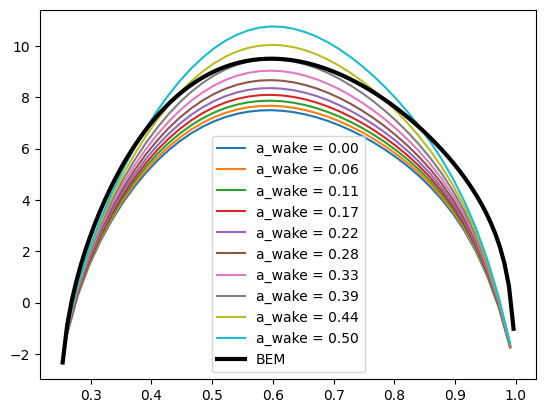

In [26]:
bem_data = pd.read_csv("data/BEM_data_1.2.csv")
for i in range(len(perf_lst)):
    plt.plot(perf_lst[i]["r_R"][:n_elem],perf_lst[i]["alpha"][:n_elem],label=f"a_wake = {a_wake_lst[i]:.2f}")
plt.plot(bem_data["r_R"], bem_data["alpha"],label = "BEM",color="black",linewidth=3)
plt.legend()